In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import string
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import linregress

import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patheffects as path_effects
from matplotlib.patches import PathPatch
import matplotlib.cm as cm
import matplotlib.colors as mcolors


import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader

import warnings
warnings.filterwarnings('ignore')

In [ ]:
def compute_enso_avg_anomalies(df, variable, enso_col='ENSO_Value',
                               threshold_el=0.5, threshold_ln=-0.5,
                               exclude_states=None):
    """
    Compute average anomalies for El Niño and La Niña given a DataFrame
    with a STATE column instead of per-state columns.

    Parameters:
    - df: input DataFrame
    - variable: str, name of the anomaly variable column (e.g., 'PRECIP_ANOM_MEAN')
    - enso_col: str, column name of ENSO index
    - threshold_el: float, El Niño threshold
    - threshold_ln: float, La Niña threshold
    - exclude_states: list or set of states to exclude

    Returns:
    - el_nino_df, la_nina_df: DataFrames with average anomalies by state
    """

    if exclude_states is None:
        exclude_states = {'DC', 'AK', 'HI', 'PR'}

    # Filter ENSO phases
    el_nino_data = df[df[enso_col] >= threshold_el]
    la_nina_data = df[df[enso_col] <= threshold_ln]

    # Compute state-level averages for each ENSO phase
    el_nino_df = (
        el_nino_data[~el_nino_data["STATE_ABBR"].isin(exclude_states)]
        .groupby("STATE_ABBR")[variable]
        .mean()
        .reset_index(name="Avg_Anomaly")
        .sort_values("Avg_Anomaly")
    )

    la_nina_df = (
        la_nina_data[~la_nina_data["STATE_ABBR"].isin(exclude_states)]
        .groupby("STATE_ABBR")[variable]
        .mean()
        .reset_index(name="Avg_Anomaly")
        .sort_values("Avg_Anomaly")
    )

    return el_nino_df, la_nina_df

In [ ]:
def plot_crash_anomalies(df,col_sel='ANOM_CRASH_COUNTS'):
    color_pos = '#D55E00'  # orange
    color_neg = '#0072B2'  # blue
    panel_bg = '#f7f7f7'   # light gray background
    font_size = 14

    # Filter for national anomalies
    anomalies = df[df['STATE_ABBR'] == 'USA'].copy()
    dates = anomalies['DATE']
    values = anomalies[col_sel]

    fig, ax = plt.subplots(figsize=(18, 6))
    
    # Plot black line
    ax.plot(dates, values, color='black', linewidth=1.5, alpha=0.3, label='_nolegend_')

    # Positive and negative masks
    mask_pos = values >= 0
    mask_neg = values < 0

    # Fill positive and negative areas
    ax.fill_between(dates, 0, values, where=mask_pos,
                    facecolor=color_pos, alpha=0.6, interpolate=True, label='Positive Anomaly')
    ax.fill_between(dates, 0, values, where=mask_neg,
                    facecolor=color_neg, alpha=0.6, interpolate=True, label='Negative Anomaly')

    # Title and labels
    ax.set_title('Monthly Fatal Crash Anomalies (1981–2019)', fontsize=font_size + 4, fontweight='bold', pad=15)
    ax.set_ylabel('Crash Anomaly', fontsize=font_size + 1, fontweight='bold')
    ax.set_xlabel('Time', fontsize=font_size + 1, fontweight='bold')

    # X ticks every year
    years = dates.dt.year.unique()
    year_start_indices = [dates[dates.dt.year == y].index[0] for y in years]
    ax.set_xticks(dates[year_start_indices])
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=font_size, fontweight='bold')

    ax.axhline(0, color='gray', linewidth=1, linestyle='--')

    # Bold spines
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Bold ticks
    ax.tick_params(axis='both', which='major', labelsize=font_size, width=1.5, length=6)

    # Grid lines on y axis
    ax.grid(axis='y', linestyle=':', alpha=0.4)

    ax.legend(fontsize=font_size, frameon=False, loc='upper right')

    plt.tight_layout(pad=2.5)
    plt.savefig('../figs/Crash_Anomalies.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


In [ ]:
def plot_nino34(df, col_sel='NINO34_SST_ANOM'):

    df = df.copy()
    
    df['DATE'] = pd.to_datetime(df[['YEAR','MONTH']].assign(DAY=1))
    
    # drop duplicates if multiple states per month
    df = df.drop_duplicates(subset=['YEAR','MONTH'])

    # sort by date
    df = df.sort_values('DATE')

    df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))
    dates = df['DATE']
    line_values = df[col_sel].values

    color_pos = '#D55E00'
    color_neg = '#0072B2'

    fig, ax = plt.subplots(figsize=(16,6))
    ax.plot(dates, line_values, color='black', linewidth=2, alpha=0.7)

    # Positive anomalies (El Nino)
    pos_values = np.clip(line_values, 0.5, None)  # clip below 0.5
    mask_pos = line_values >= 0.5
    ax.fill_between(dates, 0.5, pos_values, where=mask_pos, color=color_pos, alpha=0.7,
                    label='El Niño ≥ 0.5°C')

    # Negative anomalies (La Nina)
    neg_values = np.clip(line_values, None, -0.5)  # clip above -0.5
    mask_neg = line_values <= -0.5
    ax.fill_between(dates, neg_values, -0.5, where=mask_neg, color=color_neg, alpha=0.7,
                    label='La Niña ≤ -0.5°C')

    # Threshold lines
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(-0.5, color='gray', linestyle='--', linewidth=0.8)

    ax.set_title('Monthly NINO3.4 SST Anomalies (1981–2019)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Time', fontsize=16, fontweight='bold')
    ax.set_ylabel('SST Anomalies (°C)', fontsize=16, fontweight='bold')

    fig.autofmt_xdate(rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=12, frameon=False)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_enso_precip_anomalies(el_nino_dict, la_nina_dict, save_path=None):
    """
    Create a 2-panel horizontal bar plot of state-level precipitation anomalies
    for El Niño and La Niña events. Optimized for an 8.5x11 portrait layout.

    Parameters:
    - el_nino_dict: dict of {state: anomaly} for El Niño
    - la_nina_dict: dict of {state: anomaly} for La Niña
    - save_path: Optional path to save the figure (e.g., '../figs/output.png')
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Intersecting states, sorted alphabetically
    states = sorted(set(el_nino_dict.keys()) & set(la_nina_dict.keys()))
    el_nino_vals = np.array([el_nino_dict[state] for state in states])
    la_nina_vals = np.array([la_nina_dict[state] for state in states])

    fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True, figsize=(8.5, 11))

    color_el_nino = '#D55E00'
    color_la_nina = '#0072B2'
    title_size = 12
    label_size = 12
    tick_size = 12

    # Axis limits with margin
    def compute_limits(vals):
        vmin, vmax = vals.min(), vals.max()
        margin = 0.05
        return vmin - margin, vmax + margin

    xmin1, xmax1 = compute_limits(el_nino_vals)
    xmin2, xmax2 = compute_limits(la_nina_vals)

    # Create 0.1 spaced ticks
    def make_ticks(xmin, xmax):
        start = np.floor(xmin * 10) / 10
        end = np.ceil(xmax * 10) / 10
        return np.arange(start, end + 0.1, 0.1)

    ticks1 = make_ticks(xmin1, xmax1)
    ticks2 = make_ticks(xmin2, xmax2)

    # Plot El Niño
    ax1.barh(states, el_nino_vals, color=color_el_nino, edgecolor='black', linewidth=1.2)
    ax1.set_title('a) El Niño', fontsize=title_size, fontweight='bold')
    ax1.set_xlabel('Avg Precipitation Anomaly (mm/day)', fontsize=label_size, fontweight='bold')
    ax1.set_ylabel('State', fontsize=label_size, fontweight='bold')
    ax1.set_xlim(xmax1, xmin1)
    ax1.set_xticks(ticks1)
    ax1.grid(axis='x', linestyle=':', alpha=0.5)
    ax1.tick_params(labelsize=tick_size, width=1.5, length=5)
    ax1.invert_yaxis()
    ax1.invert_xaxis()

    # Plot La Niña
    ax2.barh(states, la_nina_vals, color=color_la_nina, edgecolor='black', linewidth=1.2)
    ax2.set_title('b) La Niña', fontsize=title_size, fontweight='bold')
    ax2.set_xlabel('Avg Precipitation Anomaly (mm/day)', fontsize=label_size, fontweight='bold')
    ax2.set_xlim(xmin2, xmax2)
    ax2.set_xticks(ticks2)
    ax2.grid(axis='x', linestyle=':', alpha=0.5)
    ax2.tick_params(labelsize=tick_size, width=1.5, length=5)

    # Style
    for ax in (ax1, ax2):
        for spine in ax.spines.values():
            spine.set_linewidth(2)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save_path:
        plt.savefig(save_path, dpi=300, facecolor='white')
    plt.show()

In [ ]:
def plot_cluster_composites(cluster_comp, cmap='RdBu_r', lon_0=260,
                             suptitle="ERA5 Z500 Anomalies DJF 1981–2019", 
                             nrows=2, ncols=2, levels=np.arange(-90, 100, 10),
                             save_path=None, dpi=300):

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.5, 11.0),
                            subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=lon_0)})

    axs = axs.flatten()
    titles = cluster_comp['names'].values
    freq=cluster_comp['freq'].values
    k = 0

    # Create circular Path in Axes coordinates
    theta = np.linspace(0, 2 * np.pi, 100)
    circle_x = 0.5 + 0.5 * np.cos(theta)
    circle_y = 0.5 + 0.5 * np.sin(theta)
    circle_path = Path(np.column_stack([circle_x, circle_y]))

    for ax, label in zip(axs, string.ascii_lowercase):
        # Apply circular boundary using Path
        ax.set_boundary(circle_path, transform=ax.transAxes)

        ax.set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        #ax.gridlines(draw_labels=False)

        cs = ax.contourf(cluster_comp['lon'].values,
                         cluster_comp['lat'].values,
                         cluster_comp['z'][k, :, :].values,
                         levels=levels,
                         cmap=cmap,
                         extend='both',
                         transform=ccrs.PlateCarree())

        title_text = f"({label}) {titles[k]} ({freq[k]}%)" if freq is not None else titles[k]
        ax.set_title(title_text, loc='center', fontsize='medium', fontweight='bold')
#        ax.text(0.01, 0.99, f"({label})", transform=ax.transAxes,
#                ha='left', va='top', fontsize='large', fontweight='bold')
        k += 1

    # fig.subplots_adjust(bottom=0.1, top=0.92, hspace=0.25)
    fig.subplots_adjust(bottom=0.25, top=0.92, hspace=0.05)
    cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("m")

    fig.suptitle(suptitle, fontsize='x-large')

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

In [ ]:
def plot_precip_cluster_composites(cluster_pcomp, titles=None,cmap='BrBG', lon_0=260,
                                    suptitle="CHIRPS Global Precip Anomalies DJF 1981–2019",
                                    nrows=2, ncols=2, levels=np.arange(-1, 1.2, 0.2),
                                    extent=[225, 300, 20, 50],
                                    save_path=None, dpi=300):

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(11.0,8.5),
                            subplot_kw={'projection': ccrs.PlateCarree(central_longitude=lon_0)})
    axs = axs.flatten()
    k = 0

    for ax, label in zip(axs, string.ascii_lowercase):
        # Set map extent
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)

        # Filled contour plot
        cs = ax.contourf(cluster_pcomp['lon'].values,
                         cluster_pcomp['lat'].values,
                         cluster_pcomp['precip'][k, :, :].values,
                         levels=levels,
                         cmap=cmap,
                         extend='both',
                         transform=ccrs.PlateCarree())

        # Title with subplot label
        ax.set_title(f"({label}) {titles[k]}", loc='center', fontsize='medium', fontweight='bold')
        k += 1

    # Adjust spacing and add colorbar
    fig.subplots_adjust(bottom=0.25, top=0.90, hspace=0.15)
    cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("mm/day", fontweight='bold')

    # Super title
    #fig.suptitle(suptitle, fontsize='x-large', fontweight='bold')

    # Save or show
    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


In [8]:
def plot_statewise_precip_anomalies(
    gdf_precip, regime_names=None,
    cmap='BrBG',
    suptitle="State-Level Precip Anomalies by Regime (DJF 1981–2019)",
    extent=[-125, -66.5, 24, 50],
    nrows=2, ncols=2,
    save_path=None, dpi=300):

    # Set up color range based on data
    abs_max = np.nanmax(np.abs(gdf_precip['ANOMALY']))
    norm = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)
    cmap = cm.get_cmap(cmap)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 9),
                            subplot_kw={'projection': ccrs.PlateCarree()})
    axs = axs.flatten()

    regimes = sorted(gdf_precip['REGIME'].dropna().unique())

    for i, (regime, ax) in enumerate(zip(regimes, axs)):
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)

        subset = gdf_precip[gdf_precip['REGIME'] == regime]

        # Plot filled states
        subset.plot(column='ANOMALY',
                    cmap=cmap,
                    norm=norm,
                    linewidth=0.5,
                    edgecolor='black',
                    ax=ax,
                    transform=ccrs.PlateCarree())

        label = regime_names.get(regime, f"Regime {regime}") if regime_names else f"Regime {regime}"
        ax.set_title(f"({string.ascii_lowercase[i]}) {label}", fontsize='medium', fontweight='bold')

    # Colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []  # required for older matplotlib

    fig.subplots_adjust(bottom=0.15, top=0.92, hspace=0.2)
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Precip Anomaly (mm/day)", fontweight='bold')

    # Super title
    fig.suptitle(suptitle, fontsize=16, fontweight='bold')

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


In [9]:
def plot_enso_anomaly_maps(el_nino_avgs, la_nina_avgs, state_centers, save_path='../figs/enso_precip_anomalies.png'):

    fig, axes = plt.subplots(nrows=2, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})

    cmap = plt.cm.BrBG
    vmin, vmax = -0.5, 0.5
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    titles = ['a) El Niño', 'b) La Niña']
    data_dicts = [el_nino_avgs, la_nina_avgs]

    shpfilename = shapereader.natural_earth(resolution='50m',
                                            category='cultural',
                                            name='admin_1_states_provinces_lakes')
    reader = shapereader.Reader(shpfilename)
    states = list(reader.records())
    
    
    for ax, title, data in zip(axes, titles, data_dicts):
        ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')

        patches = []
        values = []

        for state in states:
            abbrev = state.attributes['postal']
            if abbrev in data:
                geom = state.geometry
                if geom.geom_type == 'Polygon':
                    polygons = [geom]
                elif geom.geom_type == 'MultiPolygon':
                    polygons = list(geom.geoms)
                else:
                    continue
                for polygon in polygons:
                    patches.append(Polygon(np.array(polygon.exterior.coords.xy).T))
                    values.append(data[abbrev])

        pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1.2)
        pc.set_array(np.array(values))
        ax.add_collection(pc)

        for state, value in data.items():            
            if state in state_centers:
                
                lon, lat = state_centers[state]
                ax.text(lon, lat, f"{state}\n{value:.2f}", ha='center', va='center',
                        fontsize=8, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=14, fontweight='bold', pad=12)

    # Shared colorbar at bottom
    #sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    #sm.set_array([])
    #cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
    #                    fraction=0.04, pad=0.05)
    #cbar.set_label('Precipitation Anomaly (mm/day)', fontsize=14)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes.ravel().tolist(),
        orientation='horizontal',
        fraction=0.04,
        pad=0.07,
        extend='both'  # <-- enables arrows at both ends
    )    
    cbar.set_label('Precipitation Anomaly (mm/day)', fontsize=14)
    #plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.subplots_adjust(left=0.07, right=0.97, top=0.97, bottom=0.2, hspace=0.08)    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [10]:
def plot_swe_anomaly_maps(el_nino_avgs, la_nina_avgs, state_centers, save_path='swe_anomalies_enso.png'):
 
    # Setup
    fig, axes = plt.subplots(nrows=2, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})
    titles = ['a) El Niño', 'b) La Niña']
    data_dicts = [el_nino_avgs, la_nina_avgs]

    cmap = plt.cm.BrBG
    vmin, vmax = -0.01, 0.01
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # Shapefile
    shpfilename = shapereader.natural_earth(resolution='50m',
                                            category='cultural',
                                            name='admin_1_states_provinces_lakes')
    reader = shapereader.Reader(shpfilename)
    states = list(reader.records())

    for ax, title, data in zip(axes, titles, data_dicts):
        ax.set_extent([-125, -66, 24, 50])
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')

        patches, values = [], []
        for state in states:
            abbrev = state.attributes['postal']
            if abbrev in data:
                geom = state.geometry
                polygons = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
                for polygon in polygons:
                    coords = np.array(polygon.exterior.coords.xy).T
                    patches.append(Polygon(coords))
                    values.append(data[abbrev])

        pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1.2)
        pc.set_array(np.array(values))
        ax.add_collection(pc)

        # Add text labels
        for state, value in data.items():
            if state in state_centers:
                lon, lat = state_centers[state]
                ax.text(lon, lat, f"{state}\n{float(value):.3f}",
                        ha='center', va='center', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
                        fraction=0.04, pad=0.07, extend='both')
    cbar.set_label('SWE Anomaly (mm)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)

    # Layout
    plt.subplots_adjust(left=0.06, right=0.96, top=0.96, bottom=0.2, hspace=0.12)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [11]:
def compute_state_precip_r2(df, crash_col='ANOM_CRASH_COUNTS', precip_col='PRECIP_ANOM_MEAN', significance_level=0.05):
    """
    Compute linear regression statistics (R², slope, p-value, significance) 
    between crash anomalies and precipitation anomalies for each state.

    Parameters:
    - df: pandas DataFrame containing columns for state, crash anomalies, and precip anomalies
    - crash_col: str, column name of crash anomaly variable
    - precip_col: str, column name of precipitation anomaly variable
    - significance_level: float, p-value threshold for significance

    Returns:
    - r2_df: pandas DataFrame with columns: STATE_ABBR, R2, slope, p_value, significant
    """
    
    results = []

    for state, group in df.groupby('STATE_ABBR'):
        group = group.dropna(subset=[crash_col, precip_col])
        
        if len(group) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(
                group[precip_col], group[crash_col]
            )
            significant = p_value < significance_level
            results.append({
                'STATE_ABBR': state,
                'R2': r_value**2,
                'p_value': p_value,
                'slope': slope,
                'significant': significant
            })
        else:
            results.append({
                'STATE_ABBR': state,
                'R2': None,
                'p_value': None,
                'slope': None,
                'significant': None
            })

    r2_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
    return r2_df


In [ ]:
def plot_r2_map_panels(r2_df, state_centers, filename_base="r2_map"):

    def draw_map(ax, col, title):
        ax.set_extent([-125, -66, 24, 50])
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=1)

        patches, values = [], []

        shp = shapereader.natural_earth('50m', 'cultural', 'admin_1_states_provinces')
        for state in shapereader.Reader(shp).records():
            abbr = state.attributes['postal']
            row = r2_df[r2_df['STATE_ABBR'] == abbr]
            if row.empty:
                continue

            r2_val = row.iloc[0][col]
            sig = row.iloc[0]['significant']
            geom = state.geometry
            polys = [geom] if geom.geom_type == 'Polygon' else geom.geoms

            for poly in polys:
                coords = list(poly.exterior.coords)
                patches.append(Polygon(coords, closed=True))
                values.append(r2_val)

        cmap = "YlGnBu"
        norm = mcolors.Normalize(vmin=0, vmax=1)

        pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1)
        pc.set_array(np.array(values))
        ax.add_collection(pc)

        for _, row in r2_df.iterrows():
            abbr = row['STATE_ABBR']
            if abbr in state_centers:
                lon, lat = state_centers[abbr]
                ax.text(lon, lat, f"{abbr}\n{row[col]:.2f}",
                        ha='center', va='center', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=13, weight='bold')
        return pc

    def make_figure(columns_titles):
        fig, axs = plt.subplots(2, 1, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})
        pcs = []
        for ax, (col, title) in zip(axs, columns_titles):
            pc = draw_map(ax, col, title)
            pcs.append(pc)
        return fig, axs, pcs[-1]

    # === Total anomalies figure ===
    rows_total = [
        ('R2', "a) Total Precip Anomaly"),
        ('R2', "b) Total SWE Anomaly")
    ]
    fig1, axs1, pc1 = make_figure(rows_total)
    cbar = fig1.colorbar(pc1, ax=axs1.ravel().tolist(), orientation='horizontal', fraction=0.035, pad=0.03, extend='max')
    cbar.set_label('R² Value', fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.15)
    fig1.savefig(f"../figs/{filename_base}_total_2x1.png", dpi=300, bbox_inches='tight')

    # === ENSO anomalies figure ===
    rows_enso = [
        ('R2', "a) ENSO Precip Anomaly"),
        ('R2', "b) ENSO SWE Anomaly")
    ]
    fig2, axs2, pc2 = make_figure(rows_enso)
    cbar2 = fig2.colorbar(pc2, ax=axs2.ravel().tolist(), orientation='horizontal', fraction=0.035, pad=0.03)
    cbar2.set_label('R² Value', fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.15)
    fig2.savefig(f"../figs/{filename_base}_enso_only_2x1.png", dpi=300, bbox_inches='tight')

    plt.show()


In [13]:
def compute_statewise_regime_anomalies(df_fars, ds_cd, ds_comp, regime_months=[12, 1, 2], decorr_time=28):
    df_fars = df_fars.copy()
    df_fars['DATE'] = pd.to_datetime(df_fars[['YEAR', 'MONTH', 'DAY']], errors='coerce')
    df_fars['STATE'] = df_fars['STATE'].astype(str).str.zfill(2)

    daily_by_state = df_fars.groupby(['STATE', 'DATE']).size().reset_index(name='CRASH_COUNT')
    daily_by_state['DOY'] = daily_by_state['DATE'].dt.dayofyear
    clim = daily_by_state.groupby(['STATE', 'DOY'])['CRASH_COUNT'].mean().reset_index(name='CLIM_MEAN')
    daily_by_state = daily_by_state.merge(clim, on=['STATE', 'DOY'])
    daily_by_state['CRASH_ANOMALY'] = daily_by_state['CRASH_COUNT'] - daily_by_state['CLIM_MEAN']

    filtered_ds = ds_cd.sel(time=ds_cd['time.month'].isin(regime_months))
    df_clusters = filtered_ds[['cluster']].to_dataframe().reset_index()
    df_clusters.rename(columns={'time': 'DATE', 'cluster': 'REGIME'}, inplace=True)
    df_clusters['DATE'] = pd.to_datetime(df_clusters['DATE'])
    df_clusters['REGIME'] = df_clusters['REGIME'].astype(int)

    merged = daily_by_state.merge(df_clusters[['DATE', 'REGIME']], on='DATE', how='inner')
    mean_by_regime_state = merged.groupby(['REGIME', 'STATE'])['CRASH_ANOMALY'].mean().reset_index()

    counts = merged.groupby(['REGIME', 'STATE']).size()
    effective_n = (counts / decorr_time).astype(int)
    ci_dict = {}
    for (reg, state), group_df in merged.groupby(['REGIME', 'STATE']):
        sample = group_df['CRASH_ANOMALY'].dropna()
        sem = sample.sem()
        dfree = effective_n.get((reg, state), 0) - 1
        ci_dict[(reg, state)] = stats.t.ppf(0.975, df=dfree) * sem if dfree > 0 else np.nan

    mean_by_regime_state['CI'] = mean_by_regime_state.apply(
        lambda row: ci_dict.get((row['REGIME'], row['STATE']), np.nan), axis=1
    )
    if 'names' in ds_comp:
        regime_names = {i: str(name.values) for i, name in enumerate(ds_comp['names'])}
        mean_by_regime_state['REGIME_NAME'] = mean_by_regime_state['REGIME'].map(regime_names)

    return mean_by_regime_state


In [14]:
def compute_statewise_regime_anomalies_pct(df_fars, ds_cd, ds_comp, states_map):
    """
    Compute mean crash anomaly as percent of total crashes in each state by weather regime.

    Parameters:
    - df_fars: DataFrame with columns ['YEAR', 'MONTH', 'DAY', 'STATE'] representing crash records
    - ds_cd: xarray Dataset/DataArray with daily regime cluster assignment ('cluster'), time coordinate
    - ds_comp: Dataset or object with regime names in ds_comp['names']
    - states_map: GeoDataFrame with US states polygons, with 'STATEFP' column as state FIPS codes

    Returns:
    - gdf_pct: GeoDataFrame merging states_map with percent anomalies by state and regime,
      columns: ['STATEFP', 'REGIME', 'ANOMALY_PCT', 'geometry', ...]
    """
    import scipy.stats as stats

    # 1. Prepare df_fars with datetime
    df_fars = df_fars.copy()
    df_fars['DATE'] = pd.to_datetime(df_fars[['YEAR', 'MONTH', 'DAY']], errors='coerce')

    # 2. Total crashes per state over full period (for denominator)
    total_crashes_by_state = df_fars.groupby('STATE').size().rename('TOTAL_CRASHES').reset_index()

    # 3. Aggregate daily total crashes per state
    daily_crashes_state = df_fars.groupby(['DATE', 'STATE']).size().reset_index(name='CRASH_COUNT')
    daily_crashes_state['DOY'] = daily_crashes_state['DATE'].dt.dayofyear

    # 4. Compute daily climatology by state (mean crashes by DOY and state)
    climatology_state = daily_crashes_state.groupby(['STATE', 'DOY'])['CRASH_COUNT'].mean().reset_index(name='CLIM_MEAN')

    # 5. Merge climatology to get anomalies (raw, no smoothing)
    daily_crashes_state = daily_crashes_state.merge(climatology_state, on=['STATE', 'DOY'])
    daily_crashes_state['CRASH_ANOMALY'] = daily_crashes_state['CRASH_COUNT'] - daily_crashes_state['CLIM_MEAN']

    # 6. Prepare regime dataframe filtered to DJF months (Dec, Jan, Feb)
    filtered_ds = ds_cd.sel(time=ds_cd['time.month'].isin([12, 1, 2]))
    filtered_ds['time'] = pd.to_datetime(filtered_ds['time'].values)
    df_clusters = filtered_ds[['cluster']].to_dataframe().reset_index()
    df_clusters.rename(columns={'time': 'DATE', 'cluster': 'REGIME'}, inplace=True)
    df_clusters['REGIME'] = df_clusters['REGIME'].astype(int)

    # 7. Merge daily anomalies with regimes by DATE and STATE
    merged = daily_crashes_state.merge(df_clusters[['DATE', 'REGIME']], on='DATE', how='inner')
    merged = merged.dropna(subset=['CRASH_ANOMALY', 'REGIME', 'STATE'])

    # 8. Compute mean crash anomaly per state and regime
    mean_anomaly = merged.groupby(['STATE', 'REGIME'])['CRASH_ANOMALY'].mean().reset_index(name='ANOMALY')

    # 9. Merge total crashes for denominator
    mean_anomaly = mean_anomaly.merge(total_crashes_by_state, on='STATE', how='left')

    # 10. Compute anomaly as percent of total crashes in that state
    mean_anomaly['ANOMALY_PCT'] = 100 * mean_anomaly['ANOMALY'] / mean_anomaly['TOTAL_CRASHES']

    # 11. Merge with shapefile GeoDataFrame on state FIPS codes
    mean_anomaly['STATEFP'] = mean_anomaly['STATE'].astype(str).str.zfill(2)
    gdf_pct = states_map.merge(mean_anomaly, left_on='STATEFP', right_on='STATEFP', how='left')

    return gdf_pct


def compute_statewise_precip_averages(grid_data, states_gdf, regime_number=None):
    """
    Compute average precipitation anomaly per state.

    Parameters
    ----------
    grid_data : xarray.DataArray
        2D or 3D (regime, lat, lon) data of precipitation anomalies.
    states_gdf : GeoDataFrame
        GeoDataFrame of U.S. states (already filtered to CONUS if desired).
    regime_number : int or None
        If grid_data is 3D, selects which regime to use. If 2D, leave as None.

    Returns
    -------
    GeoDataFrame with state-level mean anomalies.
    """
    # Ensure states are in lat/lon (WGS84) to match most climate data
    states = states_gdf.to_crs("EPSG:4326").copy()

    # Select 2D slice if 3D
    if grid_data.ndim == 3:
        data_2d = grid_data.isel(dim_0=regime_number)  # adjust dim_0 to match yours
    else:
        data_2d = grid_data

    lon = data_2d['lon'].values
    lat = data_2d['lat'].values
    values = data_2d.values

    transform = rasterio.transform.from_bounds(lon.min(), lat.min(), lon.max(), lat.max(),
                                               len(lon), len(lat))

    results = []
    for _, row in states.iterrows():
        geom = [mapping(row['geometry'])]

        mask = rasterio.features.rasterize(
            geom,
            out_shape=(len(lat), len(lon)),
            transform=transform,
            fill=0,
            all_touched=True,
            dtype='uint8'
        )

        masked_data = np.where(mask == 1, values, np.nan)
        mean_val = np.nanmean(masked_data)

        results.append({
            'STATEFP': row['STATEFP'],
            'STUSPS': row.get('STUSPS', None),
            'ANOMALY': mean_val,
            'geometry': row['geometry'],
            'REGIME': regime_number
        })

    return gpd.GeoDataFrame(results, crs=states.crs)


In [15]:
def plot_crash_trend_maps(data, state_centers, save_path='../figs/state_crash_trends.png'):

    fig, ax = plt.subplots(nrows=1, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})

    cmap = plt.cm.BrBG
    vmin, vmax = -0.5, 0.5
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    title = 'Fatal Crash Anomaly Trend 1981-2019'
    shpfilename = shapereader.natural_earth(resolution='50m',
                                            category='cultural',
                                            name='admin_1_states_provinces_lakes')
    reader = shapereader.Reader(shpfilename)
    states = list(reader.records())
    
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
    ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')

    patches = []
    values = []

    for state in states:
        abbrev = state.attributes['postal']
        if abbrev in data:
            geom = state.geometry
            if geom.geom_type == 'Polygon':
                polygons = [geom]
            elif geom.geom_type == 'MultiPolygon':
                polygons = list(geom.geoms)
            else:
                continue
            for polygon in polygons:
                patches.append(Polygon(np.array(polygon.exterior.coords.xy).T))
                values.append(data[abbrev])

    pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1.2)
    pc.set_array(np.array(values))
    ax.add_collection(pc)

    for state, value in data.items():            
        if state in state_centers:

            lon, lat = state_centers[state]
            ax.text(lon, lat, f"{state}\n{value:.2f}", ha='center', va='center',
                    fontsize=8, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation='horizontal',
        fraction=0.04,
        pad=0.07,
        extend='both'  # <-- enables arrows at both ends
    )    
    cbar.set_label('Anomalous Crashes per Year', fontsize=14)
    #plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.subplots_adjust(left=0.07, right=0.97, top=0.97, bottom=0.2, hspace=0.08)    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [16]:
import pandas as pd
from scipy.stats import linregress

def add_monthly_detrended_anomalies(df, state_col='STATE_ABBR', year_col='YEAR',
                                    month_col='MONTH', count_col='FATALS'):
    """
    Adds two columns to the DataFrame:
      - CRASH_ANOMALY: monthly anomaly per state (seasonally adjusted)
      - CRASH_ANOMALY_DETRENDED: monthly anomaly detrended via linear regression per state
    """
    df = df.copy()
    
    # 1️⃣ Aggregate monthly crash counts per state
    crash_monthly = (
        df.groupby([state_col, year_col, month_col], as_index=False)[count_col]
          .sum()
          .rename(columns={count_col:'CRASH_COUNT'})
    )
    
    # 2️⃣ Compute monthly mean per state (seasonal adjustment)
    monthly_mean = (
        crash_monthly.groupby([state_col, month_col], as_index=False)['CRASH_COUNT']
                     .mean()
                     .rename(columns={'CRASH_COUNT':'MONTHLY_MEAN'})
    )
    
    # 3️⃣ Merge and compute seasonal anomalies
    crash_monthly = crash_monthly.merge(monthly_mean, on=[state_col, month_col], how='left')
    crash_monthly['CRASH_ANOMALY'] = crash_monthly['CRASH_COUNT'] - crash_monthly['MONTHLY_MEAN']
    
    # 4️⃣ Create date column
    crash_monthly['DATE'] = pd.to_datetime(crash_monthly[[year_col, month_col]].assign(DAY=1))
    
    # 5️⃣ Compute detrended anomalies by state
    def detrend_state(g):
        g['_days'] = g['DATE'].map(pd.Timestamp.toordinal)
        slope, intercept, r, p, stderr = linregress(g['_days'], g['CRASH_ANOMALY'])
        g['CRASH_ANOMALY_DETRENDED'] = g['CRASH_ANOMALY'] - (slope * g['_days'] + intercept)
        return g.drop(columns=['_days'])
    
    crash_monthly = crash_monthly.groupby(state_col).apply(detrend_state).reset_index(drop=True)
    
    # 6️⃣ Merge results back to original df
    df = df.merge(
        crash_monthly[[state_col, year_col, month_col, 'CRASH_ANOMALY', 'CRASH_ANOMALY_DETRENDED']],
        on=[state_col, year_col, month_col],
        how='left'
    )
    
    return df, crash_monthly  # returns original df with new columns, and monthly summary


In [17]:
def plot_wxregimes_state_precip_anomalies(daily_summary, state_centers):
    """
    Plot mean daily precipitation anomalies by weather regime (cluster_name) for each U.S. state.

    Parameters
    ----------
    daily_summary : pd.DataFrame
        Must contain columns ['STATE_ABBR', 'cluster_name', 'PRECIP_ANOM_MEAN'].
    state_centers : dict
        Dictionary mapping STATE_ABBR to (lon, lat) for label placement.

    Notes
    -----
    Produces one panel per cluster_name showing mean PRECIP_ANOM_MEAN per state.
    """
    if state_centers is None:
        raise ValueError("state_centers dictionary must be provided")

    # --- Load continental U.S. states ---
    shpfilename = shapereader.natural_earth('50m', 'cultural', 'admin_1_states_provinces_lakes')
    gdf_states = gpd.read_file(shpfilename)
    continental = gdf_states[~gdf_states['postal'].isin(['AK', 'HI', 'PR'])].copy()
    continental = continental.rename(columns={'postal': 'STATE_ABBR'})

    # --- Filter valid rows ---
    df_plot = daily_summary.dropna(subset=['cluster_name', 'ANOM_MEAN']).copy()

    # --- Aggregate mean precipitation anomaly by state and cluster ---
    df_state_summary = (
        df_plot.groupby(['STATE_ABBR', 'cluster_name'], as_index=False)
               .agg({'ANOM_MEAN': 'mean'})
               .rename(columns={'ANOM_MEAN': 'ANOMALY'})
    )

    # --- Merge with geometry ---
    gdf_plot = continental.merge(df_state_summary, on='STATE_ABBR', how='left')

    # --- Setup plotting ---
    regimes = sorted(df_state_summary['cluster_name'].unique())
    ncols = 2
    nrows = (len(regimes) + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4*nrows),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()

    cmap = 'BrBG'
    abs_max = max(abs(gdf_plot['ANOMALY'].min()), gdf_plot['ANOMALY'].max())
    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    # --- Plot each cluster ---
    for ax, regime in zip(axes, regimes):
        ax.set_extent([-125, -66.5, 24, 50], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)

        subset = gdf_plot[gdf_plot['cluster_name'] == regime]
        subset.plot(column='ANOMALY', cmap=cmap, norm=norm,
                    linewidth=0.5, edgecolor='black', ax=ax, transform=ccrs.PlateCarree())

        # Add text labels
        for _, row in subset.iterrows():
            x, y = state_centers.get(row['STATE_ABBR'], (None, None))
            if x is not None and y is not None and not pd.isna(row['ANOMALY']):
                ax.text(x, y, f"{row['ANOMALY']:.2f}", ha='center', va='center',
                        fontsize=8, fontweight='bold')

        ax.set_title(regime, fontsize=13, fontweight='bold')

    # --- Remove extra empty panels ---
    for ax in axes[len(regimes):]:
        ax.axis('off')

    # --- Shared colorbar ---
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Mean Daily Precipitation Anomaly (mm/day)", fontweight='bold')

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

In [18]:
state_centers = {
    'AL': (-86.8, 32.8), 'AZ': (-111.7, 34.3), 'AR': (-92.4, 34.9),
    'CA': (-119.7, 36.1), 'CO': (-105.5, 39.0), 'CT': (-72.7, 41.6),
    'DE': (-75.4, 38.1), 'FL': (-81.4, 28.6), 'GA': (-83.4, 32.6),
    'ID': (-114.6, 44.4), 'IL': (-89.2, 40.0), 'IN': (-86.3, 39.9),
    'IA': (-93.5, 42.1), 'KS': (-98.4, 38.5), 'KY': (-85.3, 37.5),
    'LA': (-92.0, 31.1), 'ME': (-69.2, 45.4), 'MD': (-76.8, 39.1),
    'MA': (-69.8, 42.3), 'MI': (-84.5, 43.3), 'MN': (-94.5, 46.0),
    'MS': (-89.7, 32.7), 'MO': (-92.5, 38.4), 'MT': (-109.5, 47.0),
    'NE': (-98.3, 41.1), 'NV': (-117.1, 38.3), 'NH': (-71.1, 45),
    'NJ': (-74.7, 40.2), 'NM': (-106.2, 34.8), 'NY': (-75.5, 43.0),
    'NC': (-79.4, 35.6), 'ND': (-100.5, 47.5), 'OH': (-82.8, 40.3),
    'OK': (-97.5, 35.6), 'OR': (-120.5, 44.1), 'PA': (-77.8, 40.9),
    'RI': (-71.5, 40.2), 'SC': (-80.9, 33.9), 'SD': (-100.2, 44.4),
    'TN': (-86.4, 35.9), 'TX': (-100.1, 31.2), 'UT': (-111.7, 39.3),
    'VT': (-72.6, 44.1), 'VA': (-78.2, 37.8), 'WA': (-121.6, 47.4),
    'WV': (-80.6, 38.6), 'WI': (-90.0, 44.6), 'WY': (-107.6, 43.0)
}

# Read in datasets

In [19]:
# FARS + ENSO BY DATE Database
df_combined_monthly=pd.read_csv('../data/combined_databases/database_fars_nino34_precip_monthly.csv')

# FARS + ENSO BY STATE Database
monthly_summary = pd.read_csv('../data/combined_databases/database_fars_nino34_precip_monthly_summary_state.csv',index_col=False)

# FARS + WXRegimes BY DATE Database
daily_summary=pd.read_csv('../data/combined_databases/database_fars_wxregimes_precip_daily.csv')

# FARS + WXRegime Daily BY STATE Database
#daily_summary = pd.read_csv('../data/combined_databases/database_fars_wxregimes_precip_daily_summary_state.csv',index_col=False)

# Weather Regime Composite Files (by gridpoint)
ds_comp = xr.open_dataset('../data/wxregimes/era5_cluster_comp_z_na_DJF1981-2019.nc')
#ds_pcomp = xr.open_dataset('../data/wxregimes/era5_cluster_comp_p_na_DJF1981-2019.nc')
#df_precip = pd.read_csv('../data/FARS/old/combined_ENSO_highresprecip.csv')
#df_enso = pd.read_csv('../data/ENSO/ENSOMONTHLY.csv')
#df_swe = pd.read_csv('../data/swe/processed/processed_swe_data.csv')
#ds_cd = xr.open_dataset('../data/wxregimes/kmeans_4cluster_DJF_1981-2019_NA.nc')
#states = gpd.read_file('/data/esplab/aelyoussoufi/cb_2018_us_state_20m.shp')

In [20]:
daily_summary

,Unnamed: 0,DATE,ANOM_MEAN,ANOM_SUM,STATE_ABBR,cluster_name,CRASH_COUNT,doy,CRASH_CLIM,CRASH_ANOM
0,0,1981-01-01,-4.391150,-917.750447,AL,West Coast High,0.0,1,1.833333,-1.833333
1,1,1981-01-02,-4.417280,-923.211495,AL,West Coast High,0.0,2,1.428571,-1.428571
2,2,1981-01-03,-4.426943,-925.231093,AL,West Coast High,0.0,3,1.200000,-1.200000
3,3,1981-01-04,-4.419716,-923.720710,AL,West Coast High,0.0,4,1.500000,-1.500000
4,4,1981-01-05,-4.411256,-921.952587,AL,West Coast High,0.0,5,2.444444,-2.444444
...,...,...,...,...,...,...,...,...,...,...
168907,168907,2019-12-27,-0.507263,-227.253931,WY,Pacific Trough,0.0,361,1.000000,-1.000000
168908,168908,2019-12-28,-0.266899,-119.570896,WY,Greenland High,0.0,362,1.000000,-1.000000
168909,168909,2019-12-29,-0.526915,-236.057830,WY,Greenland High,0.0,363,NaN,NaN
168910,168910,2019-12-30,-0.526406,-235.829965,WY,Greenland High,0.0,364,1.000000,-1.000000


In [21]:
monthly_summary['DATE'] = pd.to_datetime(monthly_summary[['YEAR','MONTH']].assign(DAY=1))

In [22]:
monthly_summary

,Unnamed: 0,STATE_ABBR,YEAR,MONTH,CRASH_COUNTS,ANOM_CRASH_COUNTS,DETRENDED_CRASH_COUNTS,PRECIP_ANOM_MEAN,PRECIP_ANOM_SUM,NINO34_SST_ANOM,DATE
0,0,AL,1981,1,4,-8.102564,-7.500721,-2.909368,-7.539917e+04,-0.36,1981-01-01
1,1,AL,1981,2,6,-4.512821,-5.502426,0.921696,3.236259e+04,-0.64,1981-02-01
2,2,AL,1981,12,10,-3.051282,-1.519082,0.591149,3.064042e+04,-0.20,1981-12-01
3,3,AL,1982,1,7,-5.102564,-4.520786,0.599387,2.330056e+04,0.13,1982-01-01
4,4,AL,1982,2,6,-4.512821,-5.522490,1.879957,5.500755e+04,-0.17,1982-02-01
...,...,...,...,...,...,...,...,...,...,...,...
5263,5263,USA,2018,2,373,-32.355364,-3.190923,1.129392,2.893828e+06,-0.78,2018-02-01
5264,5264,USA,2018,12,481,-81.130649,106.020970,0.709628,4.341225e+06,0.89,2018-12-01
5265,5265,USA,2019,1,386,-87.072678,16.104334,0.526828,1.659071e+06,0.65,2019-01-01
5266,5266,USA,2019,2,411,3.887037,37.312116,0.931488,4.815332e+06,0.71,2019-02-01


## Figure 4 Crash Anomalies
*Anomalies are relative to average number of crashes for a given state and month, then summed over all states for a national anomaly. Note this is different than taking the total number of crashes nationally and then calculating normal as the national average for a given month.  This is state-relative which is important for normalizing for state populations, driving habits, climatology, etc.

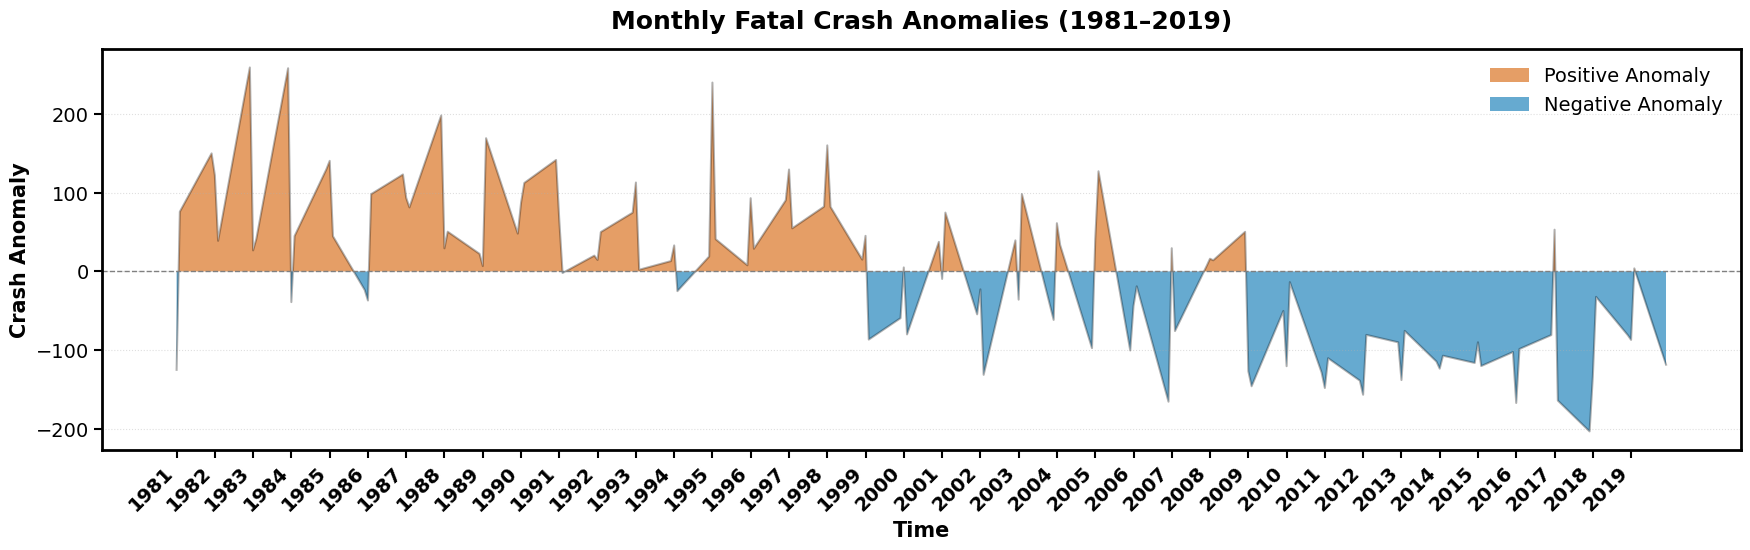

In [23]:
plot_crash_anomalies(monthly_summary,col_sel='ANOM_CRASH_COUNTS')

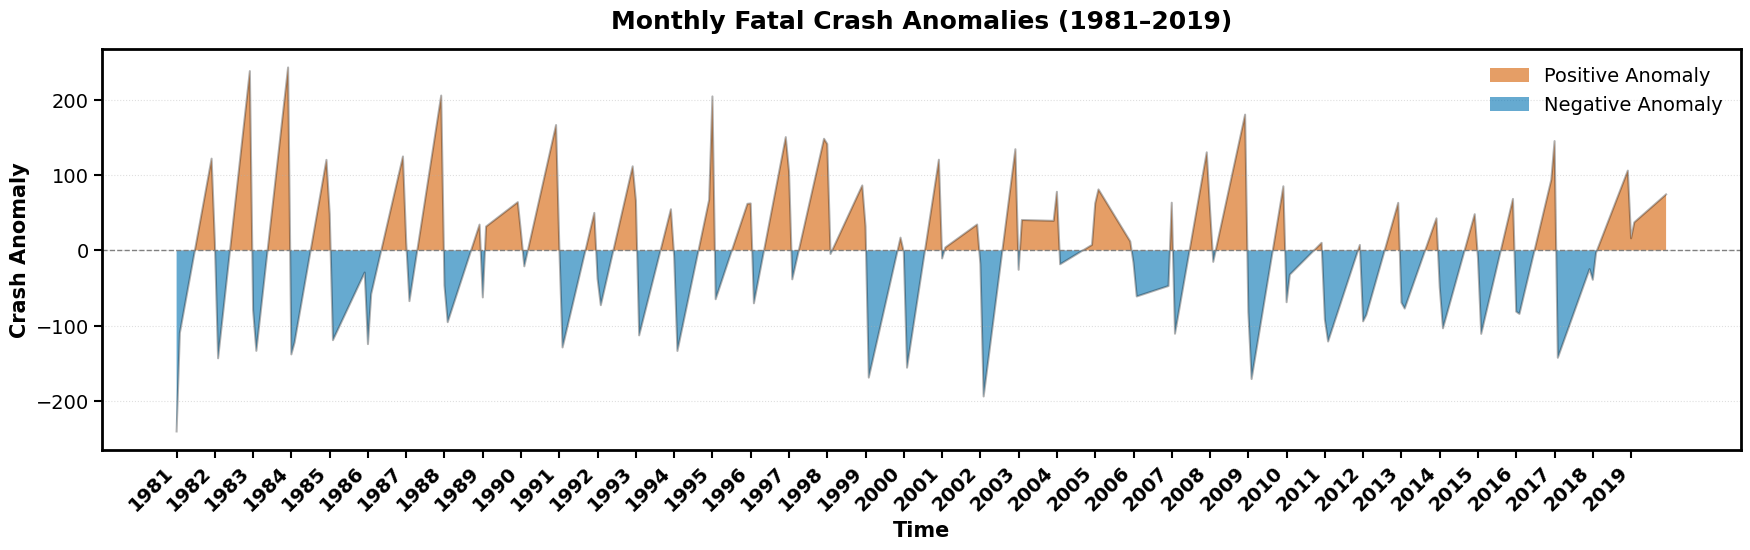

In [24]:
plot_crash_anomalies(monthly_summary,col_sel='DETRENDED_CRASH_COUNTS')

## Figure 5 Nino3.4

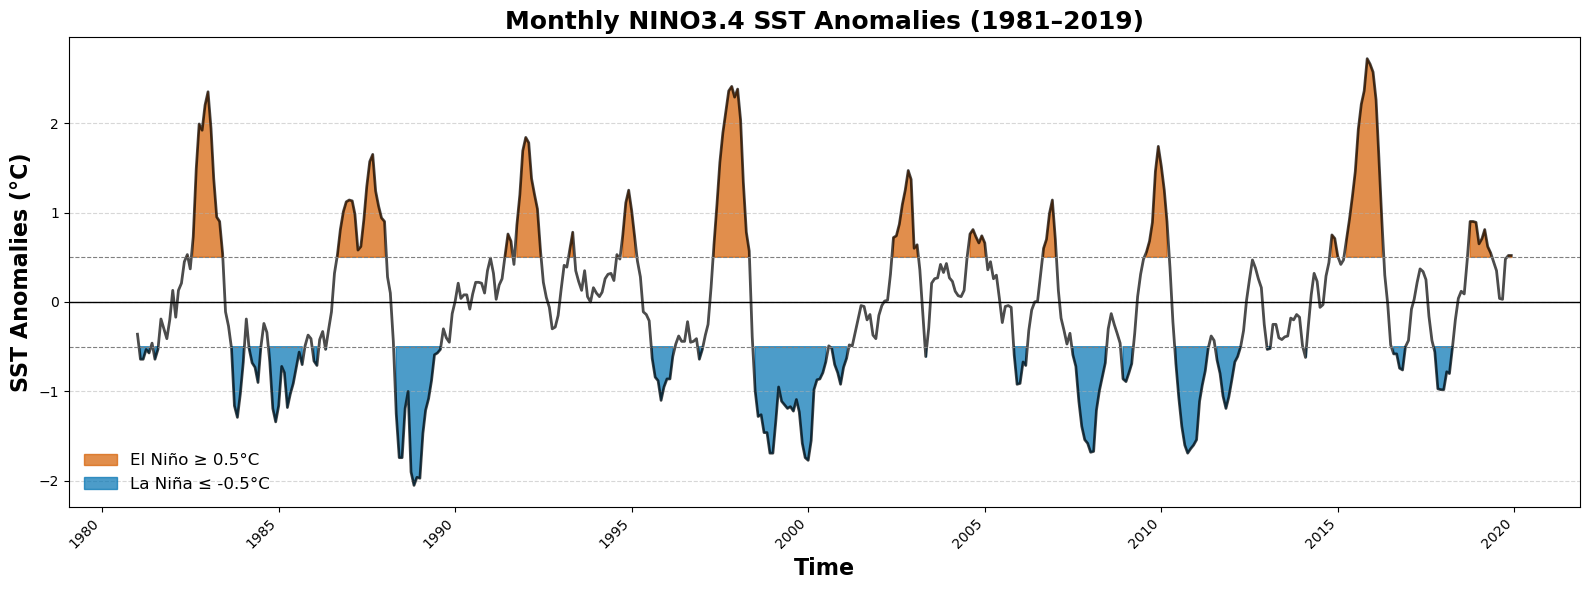

In [25]:
plot_nino34(df_combined_monthly,col_sel='SST_VALUE')

# 2. Process Get Precip Data

In [26]:
# Extract DJF
monthly_summary = monthly_summary[monthly_summary['DATE'].dt.month.isin([12, 1, 2])]

# Function to classify weather type based on WEATHER code and YEAR
def classify_precip(row):
    code, year = row['WEATHER'], row['YEAR']
    if code == 5:
        return 'Non-Precipitation'
    elif code in [6, 7]:
        return 'Non-Precipitation' if year >= 2007 else 'Precipitation'
    else:
        return 'Precipitation'

# Apply classification
df_combined_monthly.loc[:, 'WEATHER_TYPE'] = df_combined_monthly.apply(classify_precip, axis=1)

# Count crashes by WEATHER code and WEATHER_TYPE
counts = (
    df_combined_monthly
    .groupby(['WEATHER_TYPE', 'WEATHER'])
    .size()
    .reset_index(name='CRASH_COUNT')
)

# Pivot for table-style output
pivot = (
    counts
    .pivot(index='WEATHER', columns='WEATHER_TYPE', values='CRASH_COUNT')
    .fillna(0)
    .astype(int)
)

# Display result
print(pivot)

WEATHER_TYPE  Precipitation
WEATHER                    
2                    116741
3                      4543
4                     22098
6                      1385
7                       176
11                      290
12                      163


In [27]:
print(df_combined_monthly['WEATHER'].value_counts())

WEATHER
2     116741
4      22098
3       4543
6       1385
11       290
7        176
12       163
Name: count, dtype: int64


## Nino34 Precip Anomaly bar Plots & Figs 6-7

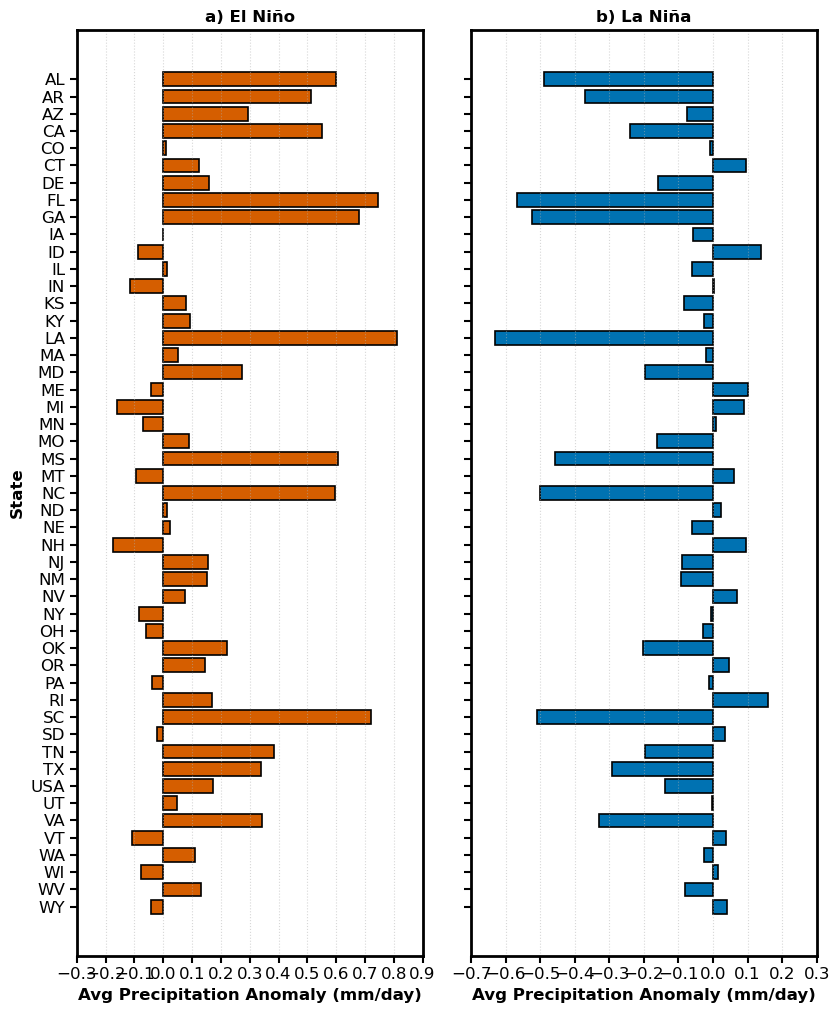

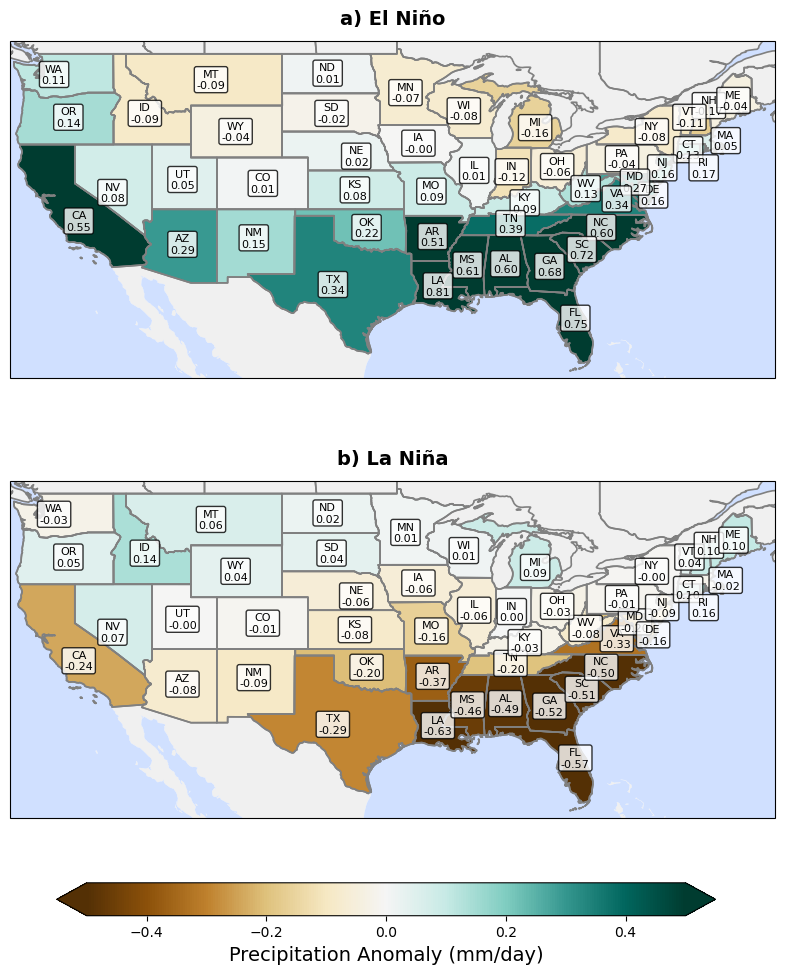

In [28]:
# Compute El Niño and La Niña average precipitation anomalies
el_nino_avgs, la_nina_avgs = compute_enso_avg_anomalies(
    monthly_summary,
    variable='PRECIP_ANOM_MEAN',
    enso_col='NINO34_SST_ANOM'
)
# Convert DataFrames -> dicts
el_nino_dict = dict(zip(el_nino_avgs["STATE_ABBR"], el_nino_avgs["Avg_Anomaly"]))
la_nina_dict = dict(zip(la_nina_avgs["STATE_ABBR"], la_nina_avgs["Avg_Anomaly"]))

# Plot precipitation anomalies for El Niño and La Niña
plot_enso_precip_anomalies(el_nino_dict, la_nina_dict,save_path='../figs/enso_precip.png')

# Plot state-level anomaly maps for El Niño and La Niña
plot_enso_anomaly_maps(el_nino_dict, la_nina_dict, state_centers)


## Figures 8-9

# Prepare ENSO data from precip_data for merging
enso_data = df_precip[['YEAR', 'Month', 'ENSO_Value']].copy()
enso_data['MONTH'] = enso_data['Month'].map(month_map)

# Filter for winter months (Dec, Jan, Feb) and years 2003+
enso_winter = enso_data[enso_data['MONTH'].isin([12, 1, 2])]
enso_winter = enso_winter[enso_winter['YEAR'] >= 2003]

# Merge with SWE data (now called sqm instead of merged_data)
swe_winter = df_swe[df_swe['MONTH'].isin([12, 1, 2])]  # Filter for winter months
swe_winter = pd.merge(swe_winter, enso_winter, on=['YEAR', 'MONTH'], how='inner')
swe_winter['snow_water_equivalent_IA']

# Compute average anomalies
el_nino_swe_df, la_nina_swe_df = compute_enso_avg_anomalies(swe_winter, 'snow_water_equivalent_')
el_nino_swe_avgs = el_nino_swe_df['Avg_Anomaly'].to_dict()
la_nina_swe_avgs = la_nina_swe_df['Avg_Anomaly'].to_dict()
plot_swe_anomaly_maps(el_nino_swe_avgs, la_nina_swe_avgs, state_centers)

## Figure 10

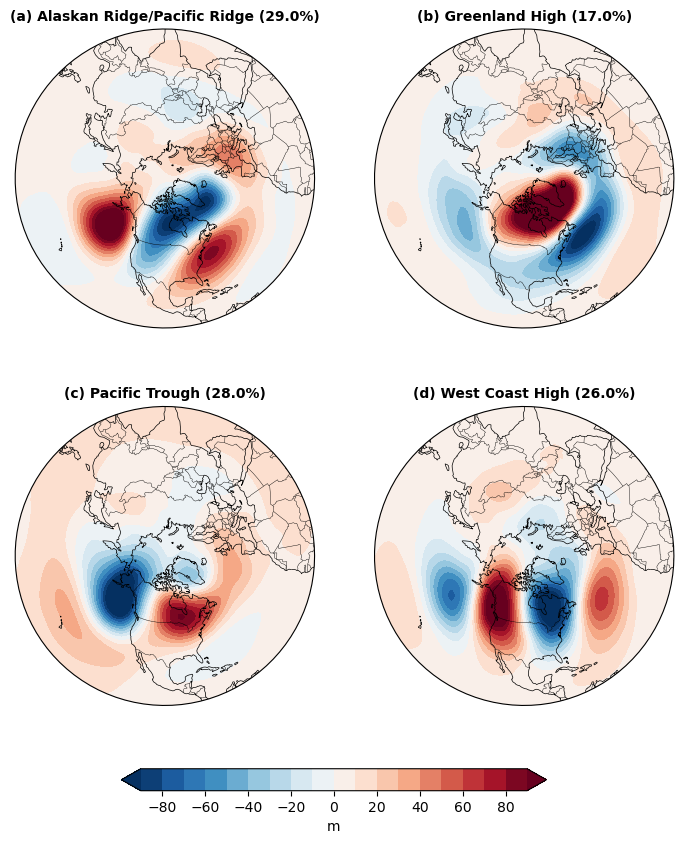

In [29]:
plot_cluster_composites(ds_comp, cmap='RdBu_r', lon_0=260,
                        suptitle=None, 
                        nrows=2, ncols=2, 
                        levels=np.arange(-90, 100, 10),
                        dpi=300,
                        save_path="../figs/cluster_composites_djf.png")

## Figure 11: Precip composite for Weather Regimes by State

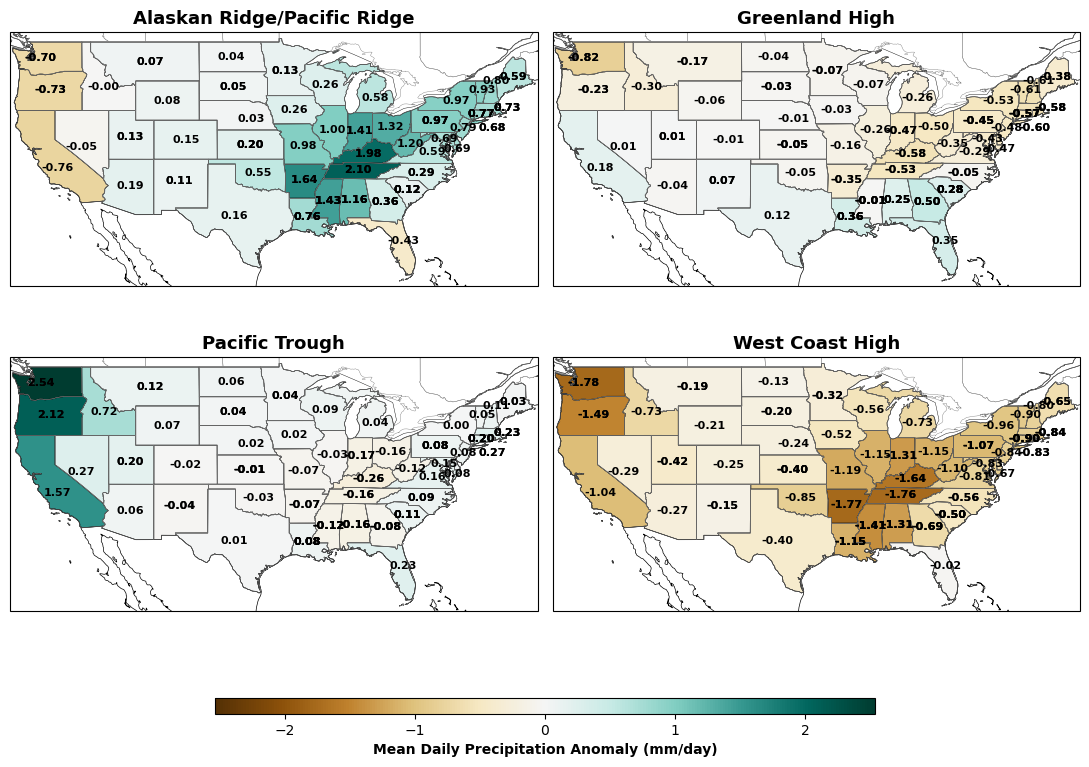

In [30]:
# Compute state × cluster composites including names

daily_summary["DATE"] = pd.to_datetime(daily_summary["DATE"])

daily_summary_djf = daily_summary[daily_summary['DATE'].dt.month.isin([12, 1, 2])]

df_composite = (
    daily_summary_djf
    .groupby(['STATE_ABBR', 'cluster_name'], as_index=False)
    .agg({'ANOM_MEAN': 'mean'})
)

plot_wxregimes_state_precip_anomalies(df_composite,state_centers=state_centers)

# 4. Calculate Precip and FWRCA Rsquared for Monthly Data

In [31]:
r2_all_results = compute_state_precip_r2(monthly_summary, 
                                         crash_col='ANOM_CRASH_COUNTS', 
                                         precip_col='PRECIP_ANOM_MEAN')

## Figures 12 & 13: Plot R-squared for Monthly Data

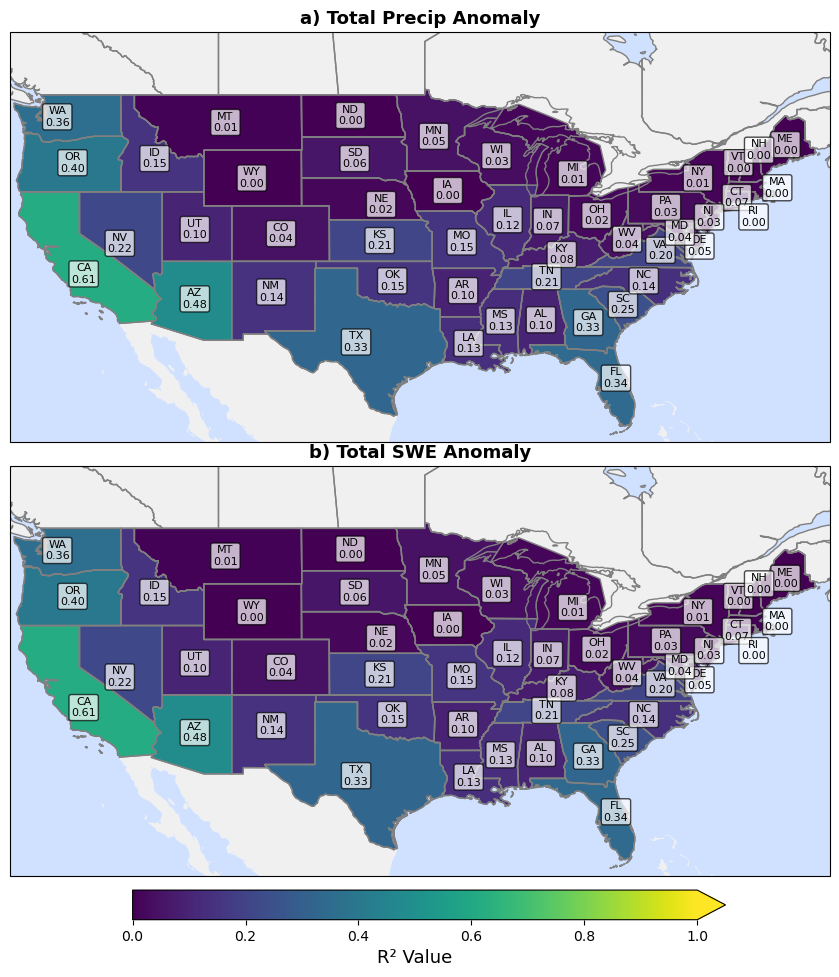

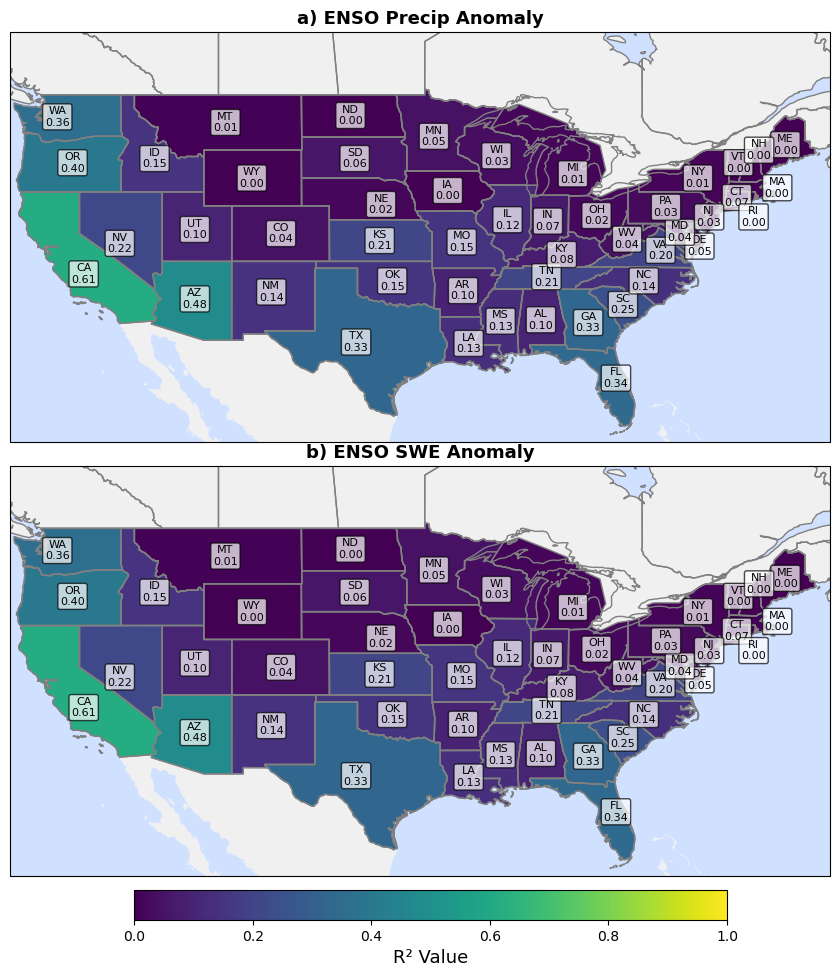

In [32]:
plot_r2_map_panels(r2_all_results, state_centers, filename_base="fwrca_r2")

## Figure 18: CONUS Crashes per day by Weather Regime

In [33]:
# Sum crashes across all states per day per cluster
daily_crashes_nationwide = (
    daily_summary
    .groupby(['DATE', 'cluster_name'], as_index=False)['CRASH_COUNT']
    .sum()  # sum across all states to get nationwide daily total
)

# Compute average daily crashes for each cluster over all days
avg_crashes_per_cluster = (
    daily_crashes_nationwide
    .groupby('cluster_name', as_index=False)['CRASH_COUNT']
    .mean()
    .rename(columns={'CRASH_COUNT': 'CRASH_COUNT_avg_daily'})
)


In [34]:
# Nationwide average per day per cluster, ignoring NaNs
daily_anom_nationwide = (
    daily_summary.groupby(['DATE', 'cluster_name'], as_index=False)['CRASH_ANOM']
    .mean()  # skipna=True by default
)


# Aggregate average daily crash anomaly per cluster
avg_anom_per_cluster = (
    daily_anom_nationwide
    .groupby('cluster_name', as_index=False)['CRASH_ANOM']
    .mean()
    .rename(columns={'CRASH_ANOM_avg': 'CRASH_ANOM_avg_daily'})
)

avg_anom_per_cluster

,cluster_name,CRASH_ANOM
0,Alaskan Ridge/Pacific Ridge,-1.290633
1,Greenland High,-1.328135
2,Pacific Trough,-1.358413
3,West Coast High,-1.386642


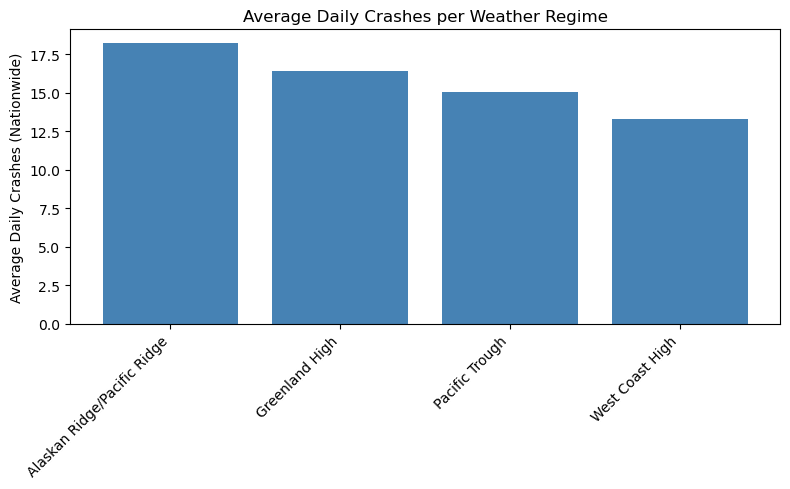

In [35]:
# Bar plot
plt.figure(figsize=(8,5))
plt.bar(avg_crashes_per_cluster['cluster_name'], avg_crashes_per_cluster['CRASH_COUNT_avg_daily'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Daily Crashes (Nationwide)')
plt.title('Average Daily Crashes per Weather Regime')
plt.tight_layout()
plt.show()